In [1]:
import trajectory_data
from dataloader import TrajectoryDataset
import matplotlib.pyplot as plt
from nocode_robot_programming.state_decision.dino_model import DINOStateDecider
from trajectory_data import skill_visualizer
from gesture_detector.utils import pretty_confusion_matrix

def predict(decider, X_train, y_train):
    y_true, y_pred = [], []
    for x,y in zip(X_train, y_train):
        is_known, y_p = decider.predict(x) #, timestep=0.0)
        # -> (True, branch_id) or (False, -1)
        y_true.append(y)
        y_pred.append(y_p)
    return y_true, y_pred

In [2]:
dataset = TrajectoryDataset(trajectory_data.package_path)
ts = dataset.timestep(idx=0, t=10)

In [3]:
decider = DINOStateDecider(dino_variant="dinov2_vits14", use_cls_token=True, batch_size=128, percent_keep=0.05)

Using cache found in /home/doma/.cache/torch/hub/facebookresearch_dinov2_main
/home/doma/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning:

xFormers is not available (SwiGLU)

/home/doma/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning:

xFormers is not available (Attention)

/home/doma/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning:

xFormers is not available (Block)



In [7]:
# video_names = ['peg_door404_trial_0', 'peg_door404_trial_1', 'peg_door404_trial_2', 'peg_door404_trial_3']
video_names = ['peg_door404_trial_0', 'peg_pick404_trial_1', 'peg_place404_trial_2']

/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:98: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.

/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:175: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



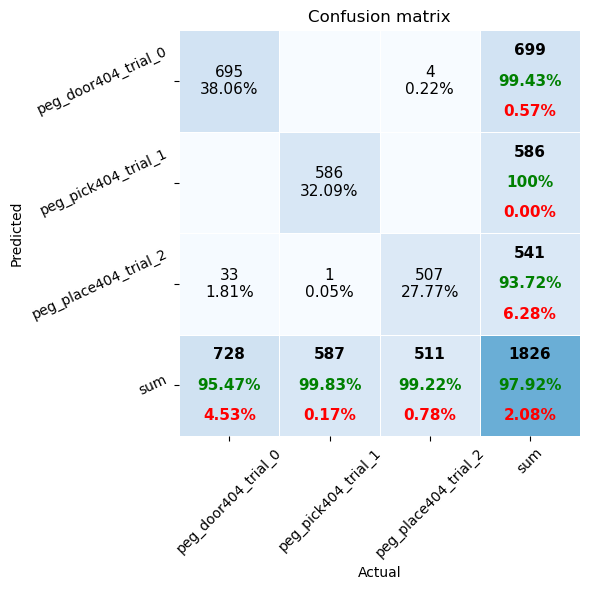

In [8]:
X_train, y_train = dataset.get_image_dataset(video_names)
decider.train(X_train, y_train)  # X_train: (N,H,W) or (N,H,W,3), y_train: (N,)
y_true, y_pred = predict(decider, X_train, y_train)
pretty_confusion_matrix.pp_matrix_from_data(y_true, y_pred, figsize=(6,6), columns=video_names)

In [6]:
y_train

tensor([0., 0., 0.,  ..., 0., 0., 0.])